In [1]:
import pystac

# STAC URL
url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"

print("Loading collection...")
collection = pystac.Collection.from_file(url)
print("Loaded successfully ✅")

Loading collection...
Loaded successfully ✅


In [2]:
items = collection.get_items()

items_list = []
LIMIT = 100

for i, item in enumerate(items):
    items_list.append(item)
    if i >= LIMIT - 1:
        break

print("Total items loaded:", len(items_list))

Total items loaded: 100


In [3]:
item = items_list[0]

print("Available assets:")
for key in item.assets.keys():
    print(key)

Available assets:
HH
metadata
preview
thumbnail


In [4]:
geo_items = []

for item in items_list:
    if 'preview' in item.assets:   # use preview (fast)
        geo_items.append(item)

print("Total usable images:", len(geo_items))

Total usable images: 100


In [5]:
import os
import rasterio
import numpy as np

os.environ["AWS_NO_SIGN_REQUEST"] = "YES"

images = []

for i, item in enumerate(geo_items):
    try:
        url = item.assets['preview'].href
        
        with rasterio.open(url) as src:
            img = src.read(1, out_shape=(256, 256))
            images.append(img)
            
        print(f"Loaded {i+1}")
        
    except:
        print(f"Error loading {i}")

Loaded 1
Loaded 2
Loaded 3
Loaded 4
Loaded 5
Loaded 6
Loaded 7
Loaded 8
Loaded 9
Loaded 10
Loaded 11
Loaded 12
Loaded 13
Loaded 14
Loaded 15
Loaded 16
Loaded 17
Loaded 18
Loaded 19
Loaded 20
Loaded 21
Loaded 22
Loaded 23
Loaded 24
Loaded 25
Loaded 26
Loaded 27
Loaded 28
Loaded 29
Loaded 30
Loaded 31
Loaded 32
Loaded 33
Loaded 34
Loaded 35
Loaded 36
Loaded 37
Loaded 38
Loaded 39
Loaded 40
Loaded 41
Loaded 42
Loaded 43
Loaded 44
Loaded 45
Loaded 46
Loaded 47
Loaded 48
Loaded 49
Loaded 50
Loaded 51
Loaded 52
Loaded 53
Loaded 54
Loaded 55
Loaded 56
Loaded 57
Loaded 58
Loaded 59
Loaded 60
Loaded 61
Loaded 62
Loaded 63
Loaded 64
Loaded 65
Loaded 66
Loaded 67
Loaded 68
Loaded 69
Loaded 70
Loaded 71
Loaded 72
Loaded 73
Loaded 74
Loaded 75
Loaded 76
Loaded 77
Loaded 78
Loaded 79
Loaded 80
Loaded 81
Loaded 82
Loaded 83
Loaded 84
Loaded 85
Loaded 86
Loaded 87
Loaded 88
Loaded 89
Loaded 90
Loaded 91
Loaded 92
Loaded 93
Loaded 94
Loaded 95
Loaded 96
Loaded 97
Loaded 98
Loaded 99
Loaded 100


In [6]:
images = np.array(images)

print("Final shape:", images.shape)

Final shape: (100, 256, 256)


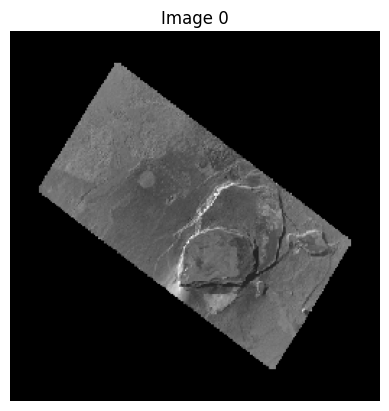

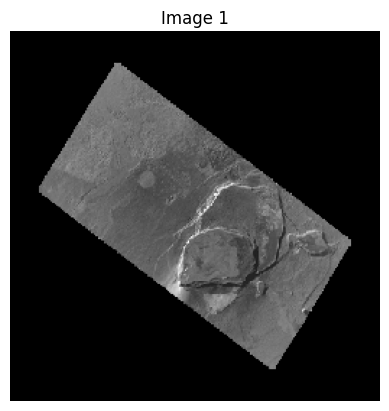

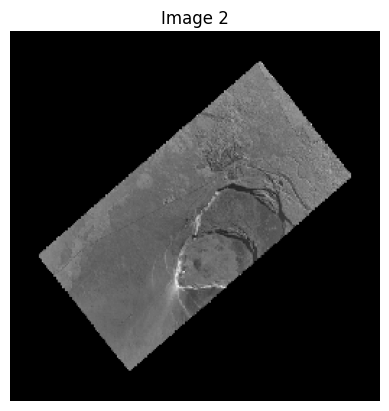

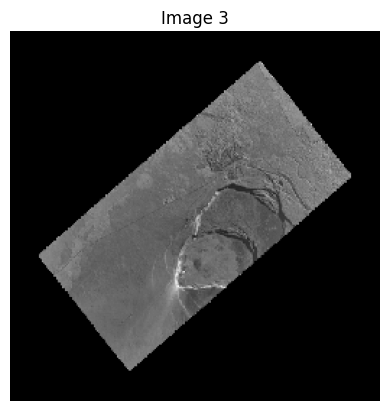

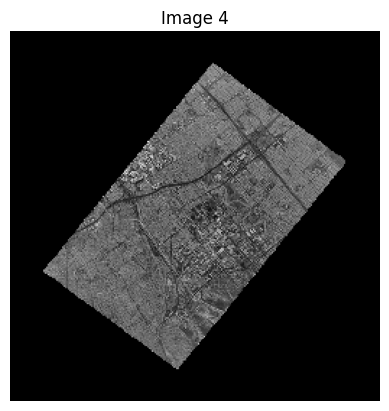

In [7]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(images[i], cmap='gray')
    plt.title(f"Image {i}")
    plt.axis('off')
    plt.show()

In [8]:
print("Min pixel:", images.min())
print("Max pixel:", images.max())

Min pixel: 0
Max pixel: 233


In [9]:
centers = []

for item in geo_items:
    coords = item.geometry['coordinates'][0]
    
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    
    lat = sum(lats) / len(lats)
    lon = sum(lons) / len(lons)
    
    centers.append((lat, lon))

In [10]:
lats = [c[0] for c in centers]
lons = [c[1] for c in centers]

print("Latitude range:", min(lats), "to", max(lats))
print("Longitude range:", min(lons), "to", max(lons))

Latitude range: 19.41153367 to 40.098905298
Longitude range: -155.28210765 to -118.08379508


In [11]:
ref_item = geo_items[0]

coords = ref_item.geometry['coordinates'][0]
ref_lon = sum([pt[0] for pt in coords]) / len(coords)
ref_lat = sum([pt[1] for pt in coords]) / len(coords)

print("Reference:", ref_lat, ref_lon)

Reference: 19.412047356 -155.28147313600002


In [12]:
filtered_items = []

THRESHOLD = 0.01   # adjust if needed

for item in geo_items:
    coords = item.geometry['coordinates'][0]
    
    lon = sum([pt[0] for pt in coords]) / len(coords)
    lat = sum([pt[1] for pt in coords]) / len(coords)
    
    if abs(lat - ref_lat) < THRESHOLD and abs(lon - ref_lon) < THRESHOLD:
        filtered_items.append(item)

print("Filtered items:", len(filtered_items))

Filtered items: 28
